In [14]:
import sqlite3
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE Users (
    user_id INTEGER PRIMARY KEY,
    join_date TEXT,
    country TEXT,
    age INTEGER,
    membership_type TEXT
)
''')

cursor.execute('''
CREATE TABLE Transactions (
    transaction_id INTEGER PRIMARY KEY,
    user_id INTEGER,
    purchase_date TEXT,
    amount REAL,
    category TEXT,
    status TEXT,
    FOREIGN KEY (user_id) REFERENCES Users(user_id)
)
''')

np.random.seed(42)
countries = ['Jordan', 'UAE', 'Saudi Arabia', 'Egypt', 'Kuwait']
memberships = ['Standard', 'Premium', 'VIP']
categories = ['Electronics', 'Clothing', 'Home', 'Beauty']
statuses = ['Completed', 'Completed', 'Completed', 'Cancelled']

for i in range(1, 101):
    join_date = (datetime(2025, 1, 1) + timedelta(days=int(np.random.randint(1, 365)))).strftime('%Y-%m-%d')
    country = np.random.choice(countries)
    age = int(np.random.randint(18, 65))
    membership_type = np.random.choice(memberships)
    cursor.execute("INSERT INTO Users VALUES (?, ?, ?, ?, ?)", (i, join_date, country, age, membership_type))

for i in range(1, 201):
    user_id = int(np.random.randint(1, 101))
    purchase_date = (datetime(2026, 1, 1) + timedelta(days=int(np.random.randint(1, 150)))).strftime('%Y-%m-%d')
    amount = round(float(np.random.exponential(scale=50) + 10), 2)
    category = np.random.choice(categories)
    status = np.random.choice(statuses)
    cursor.execute("INSERT INTO Transactions VALUES (?, ?, ?, ?, ?, ?)", (i, user_id, purchase_date, amount, category, status))

conn.commit()
print("✅ The database has been successfully created and the tables are ready to go!")

✅ The database has been successfully created and the tables are ready to go!


In [15]:
query = """
SELECT
    Transactions.transaction_id,
    Transactions.amount,
    Transactions.category,
    Transactions.status,
    Users.country,
    Users.membership_type
FROM Transactions
INNER JOIN Users ON Transactions.user_id = Users.user_id
WHERE Transactions.status = 'Completed';
"""

df = pd.read_sql_query(query, conn)

df.head()

,transaction_id,amount,category,status,country,membership_type
0,1,37.96,Beauty,Completed,Saudi Arabia,VIP
1,2,133.38,Home,Completed,Egypt,VIP
2,4,46.36,Beauty,Completed,Egypt,VIP
3,6,18.64,Clothing,Completed,Saudi Arabia,VIP
4,7,14.94,Clothing,Completed,Egypt,Standard


In [16]:
query_2 = """
SELECT
    country,
    SUM(amount) AS total_revenue,
    COUNT(transaction_id) AS total_sales
FROM Transactions
INNER JOIN Users ON Transactions.user_id = Users.user_id
WHERE status = 'Completed'
GROUP BY country
ORDER BY total_revenue DESC;
"""

df_country = pd.read_sql_query(query_2, conn)
df_country

,country,total_revenue,total_sales
0,Kuwait,3284.66,42
1,Jordan,1958.71,31
2,Egypt,1553.87,27
3,Saudi Arabia,1494.26,34
4,UAE,1290.02,26


/tmp/ipykernel_442/2149547502.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


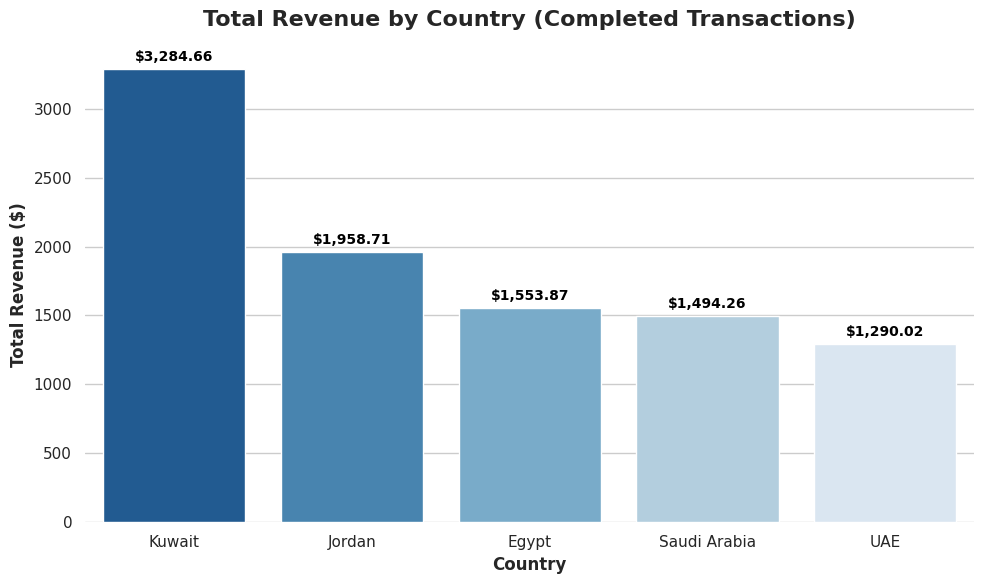

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='country',
    y='total_revenue',
    data=df_country,
    palette='Blues_r'
)

plt.title('Total Revenue by Country (Completed Transactions)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Country', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')

for p in ax.patches:
    ax.annotate(f"${p.get_height():,.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold', color='black')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [18]:
query_3 = """
SELECT
    CASE
        WHEN Users.age BETWEEN 18 AND 30 THEN 'Young Adults'
        WHEN Users.age BETWEEN 31 AND 50 THEN 'Middle Aged'
        ELSE 'Senior'
    END AS age_group,
    COUNT(Transactions.transaction_id) AS total_orders,
    SUM(Transactions.amount) AS total_spent
FROM Transactions
INNER JOIN Users ON Transactions.user_id = Users.user_id
WHERE Transactions.status = 'Completed'
GROUP BY age_group
ORDER BY total_spent DESC;
"""

df_age = pd.read_sql_query(query_3, conn)
df_age

,age_group,total_orders,total_spent
0,Middle Aged,78,5017.80
1,Young Adults,44,2307.70
2,Senior,38,2256.02


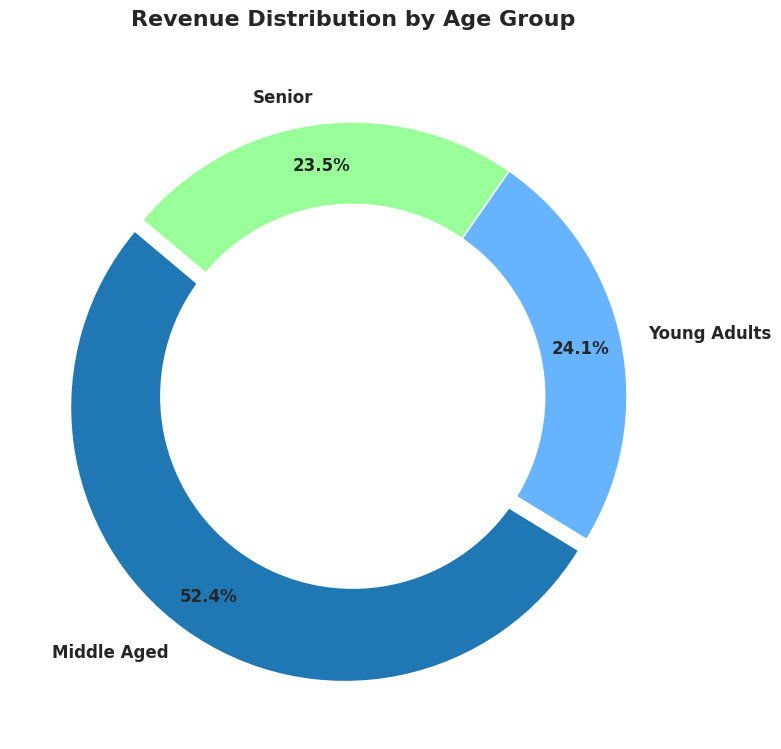

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. تجهيز البيانات والألوان
labels = df_age['age_group']
sizes = df_age['total_spent']
# تدرج ألوان متناسق ومودرن
colors = ['#1f77b4', '#66b3ff', '#99ff99']
explode = (0.05, 0, 0)  # فصل بسيط لأكبر فئة عشان تلفت الانتباه

# 2. إنشاء الرسمة الدائرية
plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%', # إظهار النسبة المئوية لكل شريحة
    startangle=140,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    pctdistance=0.85
)

# 3. تحويل الدائرة إلى Donut Chart (رسم دائرة بيضاء في المركز)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# 4. العناوين واللمسات النهائية
plt.title('Revenue Distribution by Age Group', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [20]:
query_4 = """
SELECT
    strftime('%Y-%m', purchase_date) AS purchase_month,
    COUNT(transaction_id) AS total_orders,
    SUM(amount) AS monthly_revenue
FROM Transactions
WHERE status = 'Completed'
GROUP BY purchase_month
ORDER BY purchase_month ASC;
"""

df_trend = pd.read_sql_query(query_4, conn)
df_trend

,purchase_month,total_orders,monthly_revenue
0,2026-01,28,1820.81
1,2026-02,25,1609.82
2,2026-03,37,2588.98
3,2026-04,40,2011.98
4,2026-05,30,1549.93


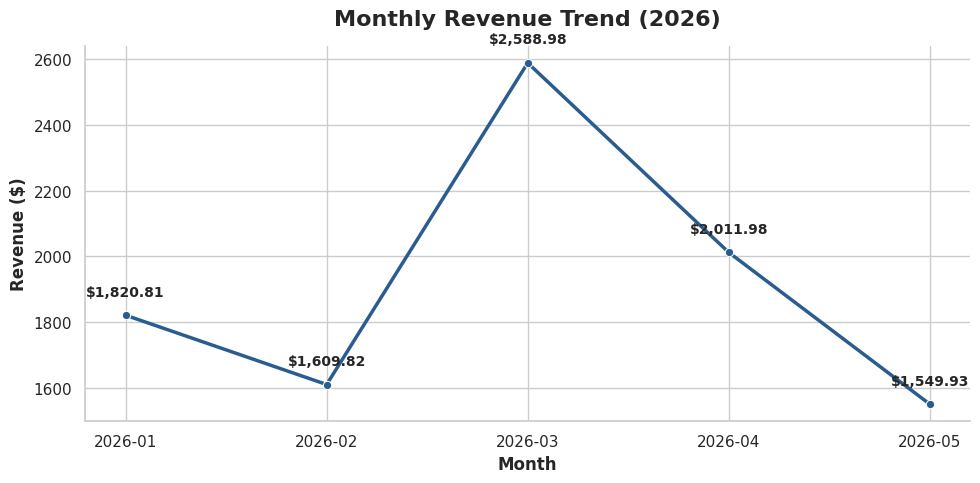

In [21]:
# رسم خط التوجهات الزمنية (Line Chart)
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# رسم الخط مع وضع نقاط (Markers) عند كل شهر
sns.lineplot(
    x='purchase_month',
    y='monthly_revenue',
    data=df_trend,
    marker='o',
    linewidth=2.5,
    color='#2b5c8f'
)

# العناوين واللمسات الأنيقة
plt.title('Monthly Revenue Trend (2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Revenue ($)', fontsize=12, fontweight='bold')

# إضافة أرقام الإيرادات فوق كل نقطة بالظبط
for x, y in zip(df_trend['purchase_month'], df_trend['monthly_revenue']):
    plt.text(x, y + 50, f"${y:,.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

## 📊 Project 1: Executive Summary & Business Insights

### 1. Key Insights:
* **Geographical Dominance:** Kuwait is driving the highest revenue ($3,284.66 across 42 orders), followed by Jordan. UAE represents the lowest revenue segment.
* **Demographic Powerhouse:** The "Middle Aged" group (ages 31-50) is our core customer segment, contributing to over half of the total revenue (52.4%), whereas "Seniors" and "Young Adults" contribute around 24% each.
* **Sales Trend Analysis:** Revenue peaked significantly in March 2026 reaching $2,588.98. However, a continuous decline is observed through April and May, indicating a need for urgent promotional interventions.

### 💡 Actionable Recommendations:
1. **Targeted Marketing:** Launch localized, high-tier membership campaigns in Kuwait and Jordan to sustain and expand high-value order volumes.
2. **Product Curation:** Tailor the platform's homepage and inventory categories to match the preferences of the "Middle Aged" segment (31-50), as they hold the highest purchasing power.
3. **Q2 Recovery Strategy:** Investigate the root cause of the revenue drop post-March (e.g., end of season, competitor pricing) and deploy targeted discounts or re-engagement emails for inactive users in June to reverse the downward trend.